<a href="https://colab.research.google.com/github/alscop/ESAA-26-1/blob/main/0508_%EC%84%B8%EC%85%98_RNN_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 넷플릭스 주가 예측하기 RNN 코드 실습

## 1. 데이터 가져오기

In [4]:
# 데이터 가져오기
import pandas as pd

data = pd.read_csv('/content/netflix_train.csv')
data.head()

,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


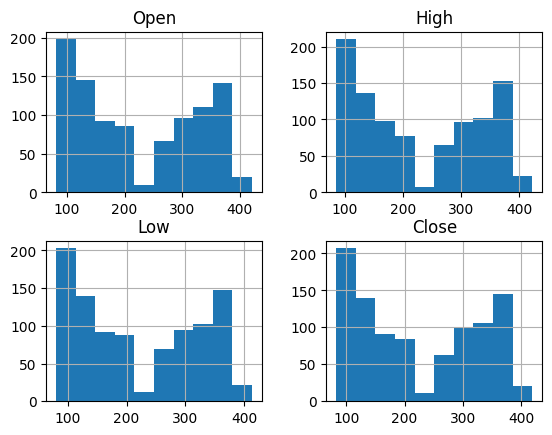

In [7]:
# 데이터 분포를 히스토그램으로 살펴보기
import matplotlib.pyplot as plt

# 개장가, 최고가, 최저가 추가
# 종가 추가
data_used = data[['Open', 'High', 'Low', 'Close']]

# 히스토그램 그리기
hist = data_used.hist()
plt.show()

## 2. 파이토치 데이터셋 구성하기

In [10]:
import numpy as np
from torch.utils.data.dataset import Dataset
from sklearn.preprocessing import MinMaxScaler # 정규화


class Netflix(Dataset):  # 클래스 선언
   def __init__(self):
       # 데이터 읽기
       self.data = pd.read_csv('/content/netflix_train.csv')

       # 입력 데이터 정규화
       self.X = self.data.iloc[:, 1:-1].values  # 종가를 제외한 데이터 추출
       self.scaler_X = MinMaxScaler()  # 0과 1 사이로 정규화
       self.X = self.scaler_X.fit_transform(self.X)

       # 종가 데이터 정규화
       self.y = self.data.iloc[:, -1].values.reshape(-1, 1)
       self.scaler_y = MinMaxScaler()
       self.y = self.scaler_y.fit_transform(self.y)

   def __len__(self):
       return len(self.data) - 30 # 사용 가능한 배치 개수
       # 전체 데이터에서 30일치를 묶어서 내보내야 하므로 마지막 30개는 제외

   def __getitem__(self, i):
       # 입력 데이터 30일치 읽기
       data = self.X[i : i+30]

       # 종가 데이터 30일치 읽기
       label = self.y[i+30]

       return data, label

정규화(MinMaxScaler): 주가는 수치 단위가 크기 때문에 $0 \sim 1$ 사이로 맞춰주지 않으면 RNN 학습이 어려움.

## 3. RNN 모델 정의

In [21]:
# RNN 클래스 정의

import torch
import torch.nn as nn

class RNN(nn.Module):
   def __init__(self):
       super(RNN, self).__init__()

       # RNN층의 정의
       self.rnn = nn.RNN(input_size=4, hidden_size=8, num_layers=1, batch_first=True)

       # 주가를 예측하는 MLP층 정의
       self.fc = nn.Linear(in_features=8, out_features=1)

       # 활성화 함수 정의
       self.relu = nn.ReLU()

# RNN 모델의 순전파 정의
   def forward(self, x, h0):
       # RNN층의 출력
       out, hn = self.rnn(x, h0)

       # MLP층의 입력으로 사용되게 모양 변경
       out = out[:, -1, :]

       # MLP층을 이용해 종가 예측
       out = self.fc(out)

       # 예측한 종가를 1차원 벡터로 표현
       return out

## 4. 모델 학습하기

In [22]:
# 모델과 데이터셋 정의
import tqdm
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델의 정의
model = RNN().to(device)

# 데이터셋의 정의
dataset = Netflix()

In [23]:
# 데이터로더 정의
# 배치 크기를 32로 설정
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [24]:
# 최적화 정의
# 학습률은 0.0001로 설정
# 사용할 최적화 설정
optimizer = Adam(params=model.parameters(), lr=0.0001)
criterion = nn.MSELoss() # 주가 예측(회귀)이므로 MSE 손실 함수 사용

In [25]:
# 학습 루프 정의
# 에포크: 200
for epoch in range(200):
   iterator = tqdm.tqdm(loader)
   for data, label in iterator:
       optimizer.zero_grad() # 최적화 초기화

       # 초기 은닉 상태
       h0 = torch.zeros(1, data.size(0), 8).to(device)

       # 모델의 예측값
       preds = model(data.float().to(device), h0)

       # 손실의 계산
       loss = criterion(preds, label.float().to(device))

       loss.backward()  # 오차 역전파
       optimizer.step()  # 최적화 진행

       iterator.set_description(f"epoch{epoch} loss:{loss.item()}")


torch.save(model.state_dict(), "netflix_rnn.pth") # 모델 저장

epoch199 loss:0.0007568272994831204: 100%|██████████| 30/30 [00:00<00:00, 114.82it/s]


## 5. 모델 성능 평가하기

In [27]:
import matplotlib.pyplot as plt

# 예측값을 위한 데이터로더 (평가용이므로 셔플하지 않습니다)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

# 예측값들을 저장하는 리스트
preds = []
total_loss = 0

with torch.no_grad():
    # 모델의 가중치 불러오기 (학습 단계에서 저장한 파일명과 동일해야 합니다)
    model.load_state_dict(torch.load("netflix_rnn.pth", map_location=device))
    model.eval() # 모델을 평가 모드로 설정

    for data, label in loader:
        # 초기 은닉 상태 정의 (input_size에 맞춰 hidden_size=8)
        h0 = torch.zeros(1, data.size(0), 8).to(device)

        # 모델의 예측값 출력 (타입 변환 및 장치 이동 주의)
        output = model(data.float().to(device), h0)

        # 예측값을 리스트에 추가 (나중에 그래프를 그리기 위해 CPU로 옮겨 저장)
        preds.extend(output.cpu().numpy())

        # 손실 계산
        loss = criterion(output, label.float().to(device))
        total_loss += loss

    # 손실의 평균치 계산
    avg_loss = total_loss / len(loader)


total_loss.item()

0.02378532476723194

In [28]:
import matplotlib.pyplot as plt

# 예측값을 위한 데이터로더 (평가용이므로 셔플하지 않습니다)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

# 예측값들을 저장하는 리스트
preds = []
total_loss = 0

with torch.no_grad():
    # 모델의 가중치 불러오기 (학습 단계에서 저장한 파일명과 동일해야 합니다)
    model.load_state_dict(torch.load("netflix_rnn.pth", map_location=device))
    model.eval() # 모델을 평가 모드로 설정

    for data, label in loader:
        # 초기 은닉 상태 정의 (input_size에 맞춰 hidden_size=8)
        h0 = torch.zeros(1, data.size(0), 8).to(device)

        # 모델의 예측값 출력 (타입 변환 및 장치 이동 주의)
        output = model(data.float().to(device), h0)

        # 예측값을 리스트에 추가 (나중에 그래프를 그리기 위해 CPU로 옮겨 저장)
        preds.extend(output.cpu().numpy())

        # 손실 계산
        loss = criterion(output, label.float().to(device))
        total_loss += loss

    # 손실의 평균치 계산
    avg_loss = total_loss / len(loader)

print(f"평균 손실: {avg_loss.item():.6f}")

평균 손실: 0.000793


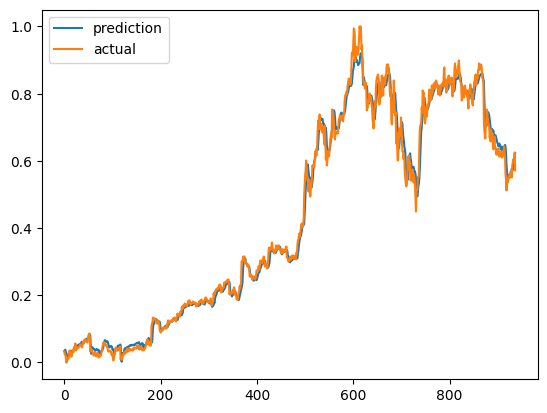

In [30]:
# 그래프 출력
plt.plot(preds, label="prediction")
plt.plot(dataset.y[30:], label="actual")
plt.legend()
plt.show()

거의 잘 맞는 모습!